# Chapter 17 — Wireless Communication Overview: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks at the end of each section. All exercises run in Google
> Colab with no additional hardware, and use only NumPy, Matplotlib, and
> pandas.

| Exercise | Topic | Key technique |
|----------|-------|---------------|
| 17.1 | Mapping the IoT wireless landscape | Illustrative dataset + a computed Pareto-frontier test (range vs. data rate) |
| 17.2 | Free-space path loss and why frequency matters for range | Friis/log-distance path-loss model across representative sub-GHz and microwave IoT bands |
| 17.3 | Bandwidth, noise, and the Shannon capacity limit | Thermal noise floor and Shannon-Hartley capacity |
| 17.4 | Radio energy budgets and the sleep-current break-even point | Generic two-parameter energy model; closed-form break-even interval |

**Note on scope.** This chapter introduces general concepts -- requirements,
taxonomy, and the range/power/data-rate/latency trade-off space -- that
Chapters 18-21 build on with protocol-specific detail (Wi-Fi and BLE in
Ch.18, ZigBee and Thread in Ch.19, LoRaWAN and Sigfox in Ch.20, NB-IoT and
LTE-M in Ch.21). The tools developed here (path loss, channel capacity,
energy budgeting) are deliberately technology-agnostic and, where a
result could be mistaken for a precise real-world figure, the analysis
says explicitly why it should not be read that way.

---

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 1.6,
})

print("Environment ready.")

Environment ready.


---

## Exercise 17.1: Mapping the IoT Wireless Landscape

In [2]:
# ── Exercise 17.1: mapping the IoT wireless landscape ───────────────────
# Illustrative reference dataset (see Chapter text, Table 17.2). PHY data
# rate follows the cited standard for each technology (Bluetooth Core
# Specification, IEEE 802.11-2024, CSA Zigbee FAQ, IEEE 802.15.4, Thread
# 1.4.0 Specification, IEEE 802.11ah, LoRaWAN specification, Sigfox
# technical documentation, 3GPP TR 45.820); range and TX-mode DC power
# are separate, implementation-dependent illustrative estimates that no
# PHY standard specifies. These are order-of-magnitude illustrative
# figures, NOT certified per-device specifications -- Chapters 18-21
# give protocol-specific, fully cited figures.
data = [
    # name, family, range_km_min, range_km_max, rate_kbps_min, rate_kbps_max, power_mw_min, power_mw_max
    ("BLE",         "Short-range",    0.010, 0.050,     125,    2000,    5,  15),
    ("Wi-Fi",       "Short-range",    0.010, 0.050,   10000,  500000,  200, 500),
    ("ZigBee",      "Mesh",           0.010, 0.100,     100,     500,   30,  50),
    ("Thread",      "Mesh",           0.010, 0.100,     250,     250,   30,  50),
    ("Wi-Fi HaLow", "Medium-range",   0.100, 1.000,    1000,    8000,   50, 150),
    ("LoRaWAN",     "LPWAN",          2.000, 15.00,     0.3,      50,   20, 100),
    ("Sigfox",      "LPWAN",          3.000, 50.00,     0.1,     0.6,   20, 100),
    ("NB-IoT",      "Cellular LPWAN", 1.000, 10.00,      20,     250,  200, 500),
    ("LTE-M",       "Cellular LPWAN", 1.000, 10.00,     100,    1000,  200, 500),
]
df = pd.DataFrame(data, columns=["technology", "family", "range_km_min", "range_km_max",
                                  "rate_kbps_min", "rate_kbps_max",
                                  "power_mw_min", "power_mw_max"])

# Representative point = geometric mean of the illustrative interval
# (appropriate on log-scaled axes; NOT a claim about a "typical" device).
df["range_km"]  = np.sqrt(df["range_km_min"]  * df["range_km_max"])
df["rate_kbps"] = np.sqrt(df["rate_kbps_min"] * df["rate_kbps_max"])
df["power_mw"]  = np.sqrt(df["power_mw_min"]  * df["power_mw_max"])

family_colors = {
    "Short-range":     "#1f77b4",
    "Mesh":            "#2ca02c",
    "Medium-range":    "#9467bd",
    "LPWAN":           "#d62728",
    "Cellular LPWAN":  "#ff7f0e",
}

df

,technology,family,range_km_min,range_km_max,rate_kbps_min,rate_kbps_max,power_mw_min,power_mw_max,range_km,rate_kbps,power_mw
0,BLE,Short-range,0.01,0.05,125.0,2000.0,5,15,0.022361,500.000000,8.660254
1,Wi-Fi,Short-range,0.01,0.05,10000.0,500000.0,200,500,0.022361,70710.678119,316.227766
2,ZigBee,Mesh,0.01,0.10,100.0,500.0,30,50,0.031623,223.606798,38.729833
3,Thread,Mesh,0.01,0.10,250.0,250.0,30,50,0.031623,250.000000,38.729833
4,Wi-Fi HaLow,Medium-range,0.10,1.00,1000.0,8000.0,50,150,0.316228,2828.427125,86.602540
5,LoRaWAN,LPWAN,2.00,15.00,0.3,50.0,20,100,5.477226,3.872983,44.721360
6,Sigfox,LPWAN,3.00,50.00,0.1,0.6,20,100,12.247449,0.244949,44.721360
7,NB-IoT,Cellular LPWAN,1.00,10.00,20.0,250.0,200,500,3.162278,70.710678,316.227766
8,LTE-M,Cellular LPWAN,1.00,10.00,100.0,1000.0,200,500,3.162278,316.227766,316.227766


In [3]:
# ── Pareto-frontier computation in the (range, rate) plane ──────────────
# Technology i is "dominated" if some other technology j has range_j >=
# range_i AND rate_j >= rate_i, with at least one strictly greater. This
# is computed from the geometric-mean points, not asserted by hand.
def pareto_dominated(df, xcol, ycol):
    dominated = []
    for i, row_i in df.iterrows():
        beaten = any((row_j[xcol] >= row_i[xcol]) and (row_j[ycol] >= row_i[ycol])
                     and ((row_j[xcol] > row_i[xcol]) or (row_j[ycol] > row_i[ycol]))
                     for j, row_j in df.iterrows() if j != i)
        dominated.append(beaten)
    return np.array(dominated)

df["dominated"] = pareto_dominated(df, "range_km", "rate_kbps")

print(df[["technology", "family", "range_km", "rate_kbps", "power_mw", "dominated"]]
      .to_string(index=False))
print("\nPareto-optimal (range vs. data rate):",
      ", ".join(df.loc[~df["dominated"], "technology"]))
print("Dominated in this 2-D projection:      ",
      ", ".join(df.loc[df["dominated"], "technology"]))

 technology         family  range_km    rate_kbps   power_mw  dominated
        BLE    Short-range  0.022361   500.000000   8.660254       True
      Wi-Fi    Short-range  0.022361 70710.678119 316.227766      False
     ZigBee           Mesh  0.031623   223.606798  38.729833       True
     Thread           Mesh  0.031623   250.000000  38.729833       True
Wi-Fi HaLow   Medium-range  0.316228  2828.427125  86.602540      False
    LoRaWAN          LPWAN  5.477226     3.872983  44.721360      False
     Sigfox          LPWAN 12.247449     0.244949  44.721360      False
     NB-IoT Cellular LPWAN  3.162278    70.710678 316.227766       True
      LTE-M Cellular LPWAN  3.162278   316.227766 316.227766      False

Pareto-optimal (range vs. data rate): Wi-Fi, Wi-Fi HaLow, LoRaWAN, Sigfox, LTE-M
Dominated in this 2-D projection:       BLE, ZigBee, Thread, NB-IoT


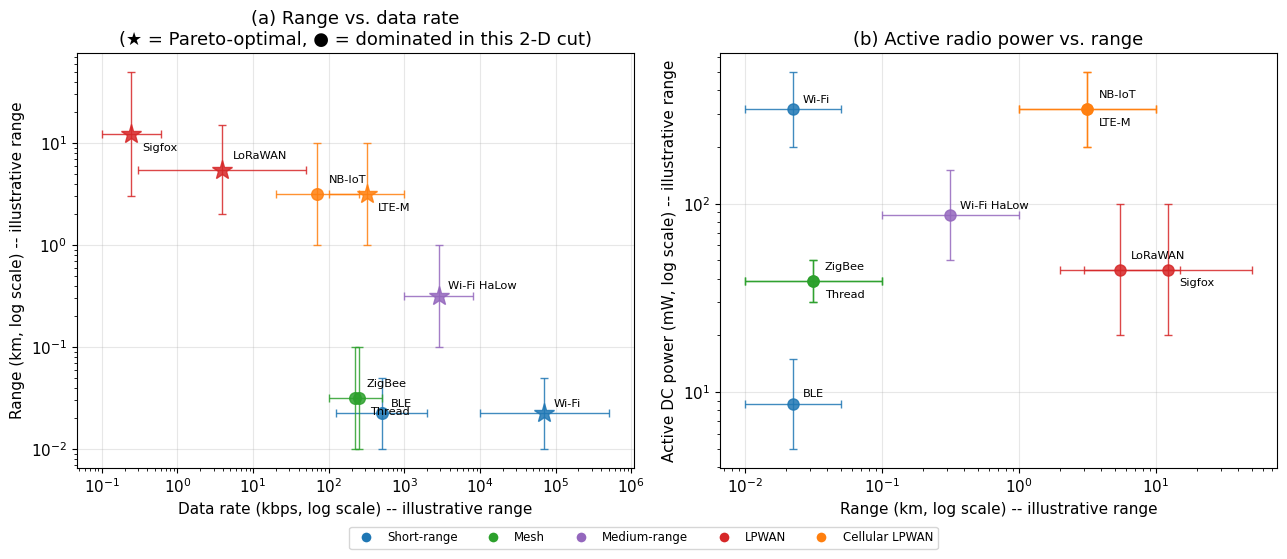

In [4]:
# ── Figure 17.1: two projections of the dataset, with error bars ───────
# Manual label offsets for pairs of points that sit close together on a
# log-log axis and would otherwise overlap (ZigBee/Thread, LoRaWAN/Sigfox,
# NB-IoT/LTE-M). Technologies not listed use the default offset.
label_offsets = {
    "ZigBee":  (8, 8),
    "Thread":  (8, -12),
    "LoRaWAN": (8, 8),
    "Sigfox":  (8, -12),
    "NB-IoT":  (8, 8),
    "LTE-M":   (8, -12),
}
DEFAULT_OFFSET = (7, 5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

# Panel (a): range vs. data rate, with error bars and Pareto marking
ax = axes[0]
for _, row in df.iterrows():
    xerr = [[row["rate_kbps"] - row["rate_kbps_min"]], [row["rate_kbps_max"] - row["rate_kbps"]]]
    yerr = [[row["range_km"] - row["range_km_min"]], [row["range_km_max"] - row["range_km"]]]
    marker = "o" if row["dominated"] else "*"
    size = 70 if row["dominated"] else 220
    ax.errorbar(row["rate_kbps"], row["range_km"], xerr=xerr, yerr=yerr,
                fmt=marker, markersize=np.sqrt(size), color=family_colors[row["family"]],
                ecolor=family_colors[row["family"]], elinewidth=1, capsize=3, alpha=0.85)
    ax.annotate(row["technology"], (row["rate_kbps"], row["range_km"]),
                textcoords="offset points",
                xytext=label_offsets.get(row["technology"], DEFAULT_OFFSET), fontsize=8.2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Data rate (kbps, log scale) -- illustrative range")
ax.set_ylabel("Range (km, log scale) -- illustrative range")
ax.set_title("(a) Range vs. data rate\n(\u2605 = Pareto-optimal, \u25cf = dominated in this 2-D cut)")

# Panel (b): power vs. range, same family colouring and error bars
ax = axes[1]
for _, row in df.iterrows():
    xerr = [[row["range_km"] - row["range_km_min"]], [row["range_km_max"] - row["range_km"]]]
    yerr = [[row["power_mw"] - row["power_mw_min"]], [row["power_mw_max"] - row["power_mw"]]]
    ax.errorbar(row["range_km"], row["power_mw"], xerr=xerr, yerr=yerr,
                fmt="o", markersize=8, color=family_colors[row["family"]],
                ecolor=family_colors[row["family"]], elinewidth=1, capsize=3, alpha=0.85)
    ax.annotate(row["technology"], (row["range_km"], row["power_mw"]),
                textcoords="offset points",
                xytext=label_offsets.get(row["technology"], DEFAULT_OFFSET), fontsize=8.2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Range (km, log scale) -- illustrative range")
ax.set_ylabel("Active DC power (mW, log scale) -- illustrative range")
ax.set_title("(b) Active radio power vs. range")

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=f)
           for f, c in family_colors.items()]
fig.legend(handles=handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.04), fontsize=8.5)

plt.tight_layout()
plt.savefig("fig_17_1_landscape.png", dpi=150, bbox_inches="tight")
plt.show()

### Analysis

Figure 17.1(a) and the printed Pareto result give a more precise version
of the qualitative claim that range and data rate trade off against
each other: in this illustrative dataset, five of the nine technologies
(Wi-Fi, Wi-Fi HaLow, LoRaWAN, Sigfox, LTE-M) form a Pareto
frontier of these particular representative operating points in the
range/rate plane, while the other four (BLE, ZigBee,
Thread, NB-IoT) are, in this specific two-dimensional projection, beaten
on both axes at once by at least one other technology.

That result needs a careful reading, and the careful reading is the
actual point of this exercise. Being "dominated" in a two-dimensional
range/rate cut does **not** mean a technology is worse overall: BLE is
dominated here only because Wi-Fi happens to share BLE's short-range
category while offering a far higher data rate -- but BLE's actual
reasons for existing (its low power, near-universal smartphone support,
and cost, none of which are axes in this particular plot) are exactly
why a wearable device would choose it over Wi-Fi. Similarly, ZigBee and
Thread are dominated here by LTE-M purely on range and rate, despite
neither requiring a cellular subscription, licensed spectrum, or
macro-cell coverage. A Pareto frontier computed over only two of this
chapter's ten requirement dimensions is a reproducible calculation,
not an opinion -- but it is a result *about those two dimensions only*.

**A further limitation worth stating explicitly:** range, data rate, and
power are computed independently above (each the geometric mean of its
own interval), but within a real radio these three are correlated --
a LoRaWAN device's longest range is reached at its *lowest* data rate,
not its highest; different BLE PHY modes trade range against rate in
specific paired combinations; Wi-Fi's MCS, bandwidth, and transmit power
jointly set all three axes at once. A technology's geometric-mean point
here may not correspond to any single real operating mode -- these
points support comparative visualisation of the landscape's shape, not
hardware selection or performance prediction.

Figure 17.1(b) adds a third, independent cut of the same dataset: active
radio power against range. Cellular technologies (NB-IoT, LTE-M) sit at
high power despite only moderate range, consistent with the general
case that closing a link through a licensed macro-cell base station from
a handset-scale antenna costs more active power than a purpose-built
LPWAN link budget at similar range.

---

## Exercise 17.2: Free-Space Path Loss and the Physics of Range

In [5]:
# ── Exercise 17.2: free-space path loss and the physics of range ───────
# Friis free-space path loss (dB), d in km, f in MHz:
#   FSPL(dB) = 20*log10(d) + 20*log10(f) + 32.44
# Generalised log-distance model with path-loss exponent n (n=2 is free
# space; n>2 models obstructions, multipath, and ground reflections):
#   L(d) = L(d0) + 10*n*log10(d/d0)
#
# NOTE: this exercise reports a PATH-LOSS-LIMITED MODEL DISTANCE -- the
# distance at which this model reaches a stated loss budget -- NOT an
# achievable real-world range. It excludes antenna gain, receiver
# sensitivity, coding gain, regulatory EIRP limits, Earth curvature, and
# real terrain beyond what the exponent n summarises.
def path_loss_db(d_km, f_mhz, n=2.0, d0_km=1.0):
    l_d0 = 20*np.log10(d0_km) + 20*np.log10(f_mhz) + 32.44
    return l_d0 + 10*n*np.log10(d_km/d0_km)

def path_loss_limited_distance_km(f_mhz, n, budget_db=140.0, d0_km=1.0):
    l_d0 = 20*np.log10(d0_km) + 20*np.log10(f_mhz) + 32.44
    return d0_km * 10 ** ((budget_db - l_d0) / (10*n))

FREQS_MHZ = {"433 MHz": 433, "868 MHz": 868, "915 MHz": 915,
             "2.4 GHz": 2400, "5.8 GHz": 5800}
colors_f = {"433 MHz": "#2ca02c", "868 MHz": "#1f77b4", "915 MHz": "#17becf",
            "2.4 GHz": "#d62728", "5.8 GHz": "#7f7f7f"}
distances = np.linspace(0.01, 20, 400)
LOSS_BUDGET_DB = 140.0

print("Path-loss model ready. Reporting an idealised model distance, not an achievable range.")

Path-loss model ready. Reporting an idealised model distance, not an achievable range.


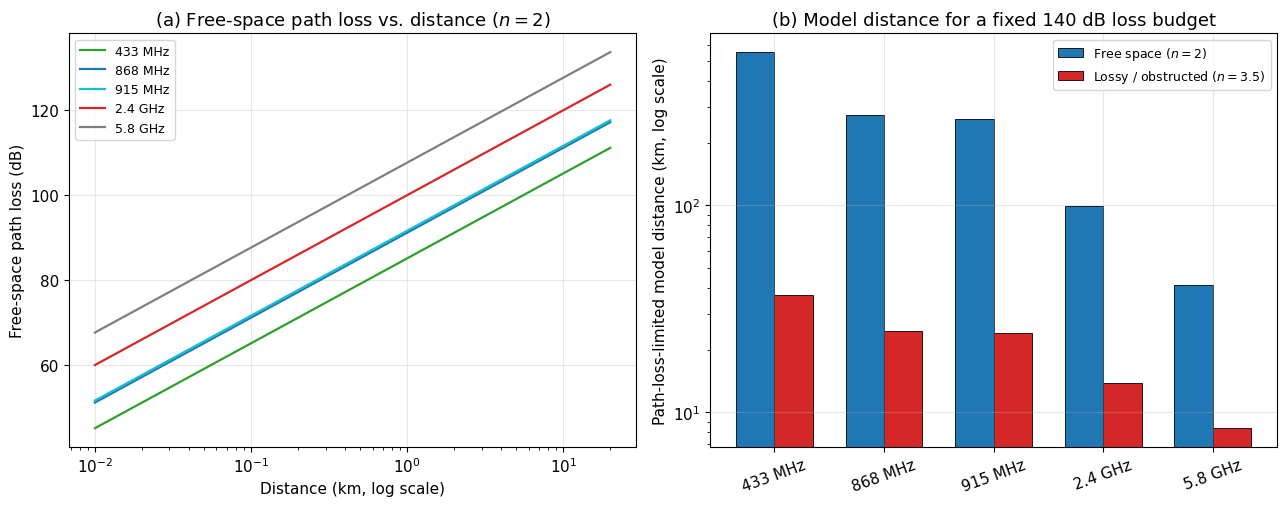

In [6]:
# ── Figure 17.2: path loss vs. distance, and model distance vs. frequency ─
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

ax = axes[0]
for label, f in FREQS_MHZ.items():
    ax.plot(distances, path_loss_db(distances, f, n=2.0),
            label=label, color=colors_f[label])
ax.set_xscale("log")
ax.set_xlabel("Distance (km, log scale)")
ax.set_ylabel("Free-space path loss (dB)")
ax.set_title("(a) Free-space path loss vs. distance ($n=2$)")
ax.legend(loc="upper left")

labels = list(FREQS_MHZ.keys())
dist_fs = [path_loss_limited_distance_km(FREQS_MHZ[l], 2.0, LOSS_BUDGET_DB) for l in labels]
dist_lossy = [path_loss_limited_distance_km(FREQS_MHZ[l], 3.5, LOSS_BUDGET_DB) for l in labels]
x = np.arange(len(labels)); width = 0.35
ax = axes[1]
ax.bar(x - width/2, dist_fs, width, label="Free space ($n=2$)",
       color="#1f77b4", edgecolor="black", linewidth=0.6)
ax.bar(x + width/2, dist_lossy, width, label="Lossy / obstructed ($n=3.5$)",
       color="#d62728", edgecolor="black", linewidth=0.6)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel("Path-loss-limited model distance (km, log scale)")
ax.set_title(f"(b) Model distance for a fixed {LOSS_BUDGET_DB:.0f} dB loss budget")
ax.legend()

plt.tight_layout()
plt.savefig("fig_17_2_pathloss.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# ── Exercise 17.2 output: model distance by frequency and environment ──
print(f"{'Frequency':<10}{'Distance n=2 (km)':>18}{'Distance n=3.5 (km)':>20}{'Ratio':>10}")
for l, r2, r35 in zip(labels, dist_fs, dist_lossy):
    print(f"{l:<10}{r2:>18.2f}{r35:>20.2f}{r2/r35:>10.2f}")

Frequency  Distance n=2 (km) Distance n=3.5 (km)     Ratio
433 MHz               551.46               36.86     14.96
868 MHz               275.09               24.77     11.10
915 MHz               260.96               24.04     10.86
2.4 GHz                99.49               13.85      7.18
5.8 GHz                41.17                8.37      4.92


### Analysis

Figure 17.2(a) shows the textbook signature of free-space propagation:
path loss grows linearly with distance on a log-distance axis, and each
doubling of frequency shifts the curve up by a fixed 6 dB, regardless of
distance -- specific to the free-space case ($n=2$); more generally,
doubling distance costs $10 n \log_{10}2$ dB. That constant vertical
offset between frequencies is one clear, physics-based reason why, all
else being equal, lower frequencies extend the distance at which a given
propagation-loss budget is exhausted -- but all else is frequently *not*
equal in a real design (antenna gain, sensitivity, coding, regulation,
and terrain all matter too).

Figure 17.2(b) and the printed table quantify the consequence for a
fixed 140 dB loss budget, purely within this idealised model. At $n=2$,
433 MHz reaches a path-loss-limited distance roughly 13x larger than
5.8 GHz -- a figure so large (over 500 km) that it is obviously never
observed in a real terrestrial deployment. The $n=3.5$ figures are more
representative of an obstructed path, bringing 433 MHz down to roughly
37 km and 5.8 GHz down to roughly 8 km -- the same qualitative ordering,
but with the sub-GHz advantage compressed from roughly 13x to roughly
4x. Chapter 20 develops a dedicated empirical model (Hata, with
log-normal shadowing) that refines this considerably; the free-space
figures here should be read as a loose, idealised free-space baseline, never a
design figure.

---

## Exercise 17.3: Bandwidth, Noise, and the Shannon Capacity Limit

In [8]:
# ── Exercise 17.3: bandwidth, noise, and the Shannon capacity limit ────
# Thermal noise floor (dBm) for bandwidth B (Hz), with receiver noise
# figure NF (dB) added on top of the ideal receiver floor:
#   N(dBm) = -174 + 10*log10(B) + NF
def noise_floor_dbm(bw_hz, nf_db=6.0):
    return -174.0 + 10*np.log10(bw_hz) + nf_db

# Shannon-Hartley: the maximum rate achievable with arbitrarily low error
# probability, under ideal coding assumptions, for bandwidth B (Hz) and
# a given SNR (dB):
def shannon_capacity_bps(bw_hz, snr_db):
    snr_lin = 10 ** (snr_db / 10)
    return bw_hz * np.log2(1 + snr_lin)

bw_hz = np.logspace(2, 8, 400)   # 100 Hz .. 100 MHz
reference_channels = [("Sigfox (100 Hz)", 100), ("LoRa (125 kHz)", 125e3),
                       ("NB-IoT (180 kHz)", 180e3), ("Wi-Fi (20 MHz)", 20e6)]
print("Shannon-Hartley model ready.")

Shannon-Hartley model ready.


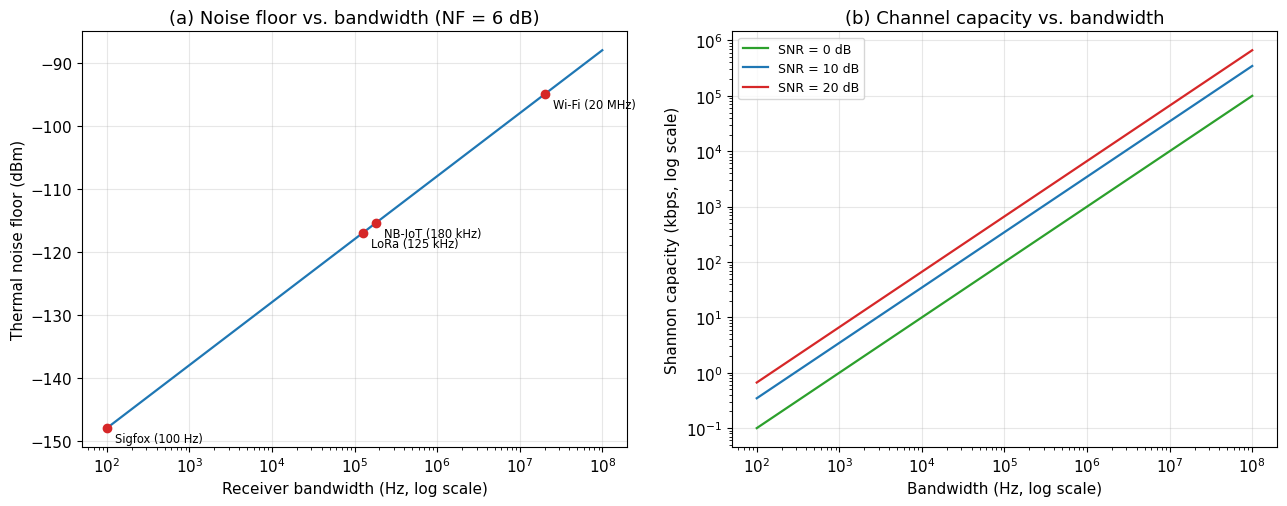

In [9]:
# ── Figure 17.3: noise floor and channel capacity vs. bandwidth ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

ax = axes[0]
ax.plot(bw_hz, noise_floor_dbm(bw_hz), color="#1f77b4")
for label, bw in reference_channels:
    ax.scatter([bw], [noise_floor_dbm(bw)], color="#d62728", zorder=5)
    ax.annotate(label, (bw, noise_floor_dbm(bw)),
                textcoords="offset points", xytext=(6, -10), fontsize=8.3)
ax.set_xscale("log")
ax.set_xlabel("Receiver bandwidth (Hz, log scale)")
ax.set_ylabel("Thermal noise floor (dBm)")
ax.set_title("(a) Noise floor vs. bandwidth (NF = 6 dB)")

ax = axes[1]
for snr_db, color in [(0, "#2ca02c"), (10, "#1f77b4"), (20, "#d62728")]:
    cap_kbps = shannon_capacity_bps(bw_hz, snr_db) / 1e3
    ax.plot(bw_hz, cap_kbps, label=f"SNR = {snr_db} dB", color=color)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Bandwidth (Hz, log scale)")
ax.set_ylabel("Shannon capacity (kbps, log scale)")
ax.set_title("(b) Channel capacity vs. bandwidth")
ax.legend()

plt.tight_layout()
plt.savefig("fig_17_3_shannon.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── Exercise 17.3 output: noise floor and capacity at reference channels ─
print("Noise floor by bandwidth (NF = 6 dB):")
for label, bw in reference_channels:
    print(f"  {label:<20}{noise_floor_dbm(bw):8.1f} dBm")

ref = noise_floor_dbm(100); wifi = noise_floor_dbm(20e6)
print(f"\nNoise-floor advantage of a 100 Hz channel over a 20 MHz channel: "
      f"{wifi - ref:.1f} dB")

print("\nCapacity at SNR = 0 dB (an illustrative operating point):")
for label, bw in reference_channels:
    print(f"  {label:<20}{shannon_capacity_bps(bw, 0)/1e3:10.2f} kbps")

Noise floor by bandwidth (NF = 6 dB):
  Sigfox (100 Hz)       -148.0 dBm
  LoRa (125 kHz)        -117.0 dBm
  NB-IoT (180 kHz)      -115.4 dBm
  Wi-Fi (20 MHz)         -95.0 dBm

Noise-floor advantage of a 100 Hz channel over a 20 MHz channel: 53.0 dB

Capacity at SNR = 0 dB (an illustrative operating point):
  Sigfox (100 Hz)           0.10 kbps
  LoRa (125 kHz)          125.00 kbps
  NB-IoT (180 kHz)        180.00 kbps
  Wi-Fi (20 MHz)        20000.00 kbps


### Analysis

Figure 17.3(a) and the printed noise-floor table quantify a fact that
often gets stated qualitatively but rarely quantitatively: narrowing the
receiver bandwidth from Wi-Fi's 20 MHz down to Sigfox's 100 Hz lowers the
thermal noise floor by 53 dB. It's important to be precise about what
this 53 dB figure is and is not: noise floor is not the same thing as
receiver sensitivity. Sensitivity also depends on the demodulator's
required SNR, the modulation and coding scheme, and implementation
losses this simplified model does not include. Sigfox's own
coverage-planning documentation states a theoretical receiver
sensitivity of -142 dBm for its 100 bps mode -- roughly 6 dB above this
exercise's computed -148 dBm noise floor for a 100 Hz channel. That gap
is not a modelling error; it may reflect the required demodulation SNR,
implementation losses, and the assumptions of this simplified model. The
same documentation also states -134 dBm for Sigfox's 600 bps mode, but
that mode is not necessarily demodulated over the same 100 Hz equivalent
noise bandwidth this exercise assumes, so it cannot be compared to the
same noise-floor figure without also knowing its actual receiver
bandwidth -- the 100 bps comparison above is the one this exercise's
assumptions actually support. The computed 100 Hz noise floor is of the
same order as the published 100 bps sensitivity figure (a useful sanity
check on the model), but it should be read as a thermal-noise floor
under stated idealised assumptions, not a complete receiver-sensitivity
specification. With that distinction in mind, narrowing bandwidth still
contributes substantially to the link margin available to a receiver
design.

Figure 17.3(b) shows the cost of that choice: at a fixed SNR, Shannon
capacity scales linearly with bandwidth, so the same noise-floor
advantage that narrowband buys comes paired with a capacity ceiling
several orders of magnitude below a wideband channel's. The 0, 10, and
20 dB values plotted are illustrative SNR points, not a claim that any
particular one represents "the" sensitivity threshold -- different
modulation and coding schemes achieve reliable demodulation at different
SNR, sometimes even negative SNR, as the LoRa example below shows. Under
the fixed-SNR and fixed-noise-figure assumptions used here, ultra-narrowband
(Sigfox), moderate spread-spectrum bandwidth (LoRa), and wideband
(Wi-Fi, cellular) illustrate different points along this
bandwidth/sensitivity trade-off -- though this is a simplified picture:
LoRa, for instance, uses a wider bandwidth than Sigfox but tolerates
negative demodulation SNR through spread-spectrum processing gain, so
bandwidth alone does not rank technologies by sensitivity once
modulation and coding are allowed to differ, as they do in practice.

---

## Exercise 17.4: Radio Energy Budgets and the Sleep-Current Break-Even

In [11]:
# ── Exercise 17.4: radio energy budgets and the sleep-current break-even ─
# A generic, protocol-agnostic radio node with two free parameters:
#   E_active_mJ : ADDITIONAL energy consumed by ONE reporting event ABOVE
#                 the idle baseline (transmit, and any associated receive
#                 activity, as a single lumped quantity -- deliberately
#                 NOT decomposed into payload size, data rate, and
#                 receive-window duration, since that decomposition is
#                 protocol-specific and belongs in Chapters 18-21 /
#                 Exercise 20.3). Defining it as an INCREMENT above idle,
#                 not a self-contained total, is what lets idle power be
#                 charged for the full interval below without double-
#                 counting that baseline a second time inside E_active.
#   I_sleep_uA  : sleep/idle current between reports.
# No protocol names are used anywhere in this exercise.
BATTERY_V = 3.6
BATTERY_MAH = 2400.0
BATTERY_MWH = BATTERY_V * BATTERY_MAH
SHELF_LIFE_CEILING_YEARS = 15.0   # illustrative primary-lithium-cell shelf life

def idle_power_mw(i_sleep_ua):
    return i_sleep_ua * BATTERY_V / 1000.0

def battery_life_years(e_active_mj, i_sleep_ua, interval_s):
    # Assumes active duration negligible vs. interval (low duty cycle).
    p_idle_mw = idle_power_mw(i_sleep_ua)
    messages_per_day = 86400.0 / interval_s
    e_active_per_day_mwh = e_active_mj * messages_per_day / 3600.0
    e_idle_per_day_mwh = p_idle_mw * 24.0
    return (BATTERY_MWH / (e_active_per_day_mwh + e_idle_per_day_mwh)) / 365.0

def break_even_interval_s(e_active_mj, i_sleep_ua):
    # Closed form: t_be = E_active / P_idle (seconds). Derived by setting
    # active energy/day == idle energy/day and using 86400/(3600*24) = 1.
    return e_active_mj / idle_power_mw(i_sleep_ua)

print(f"Battery baseline: {BATTERY_V} V, {BATTERY_MAH:.0f} mAh ({BATTERY_MWH:.0f} mWh)")

Battery baseline: 3.6 V, 2400 mAh (8640 mWh)


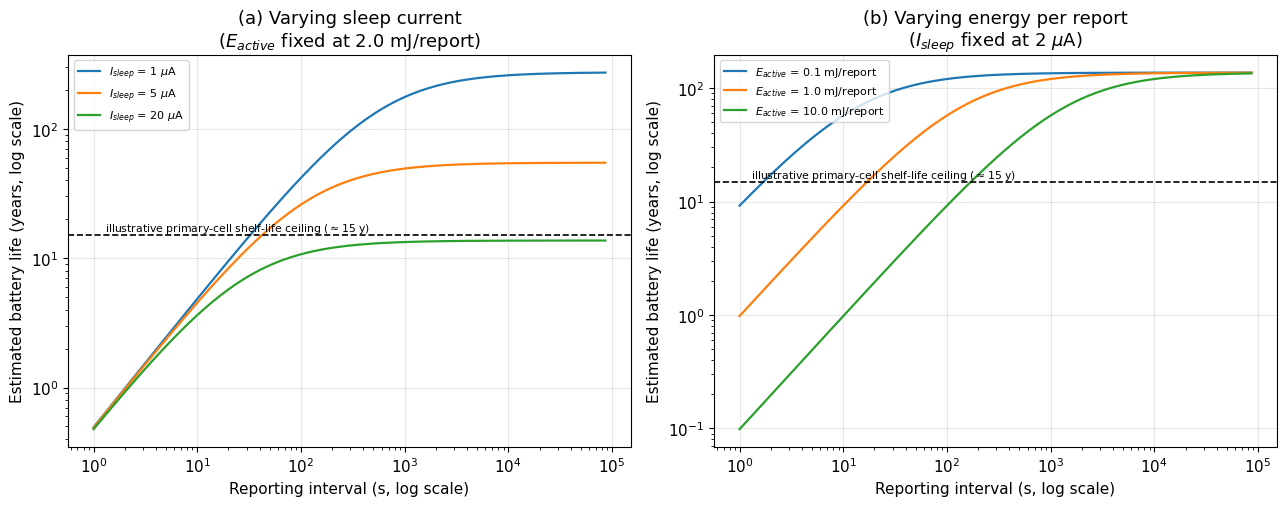

In [12]:
# ── Figure 17.4: battery life vs. interval, sweeping each parameter ─────
intervals_s = np.logspace(0, np.log10(86400), 200)
E_ACTIVE_FIXED_MJ = 2.0
I_SLEEP_FIXED_UA = 2.0
sleep_currents_ua = [1.0, 5.0, 20.0]
energies_mj = [0.1, 1.0, 10.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

ax = axes[0]
for i_sleep in sleep_currents_ua:
    life = [battery_life_years(E_ACTIVE_FIXED_MJ, i_sleep, t) for t in intervals_s]
    ax.plot(intervals_s, life, label=f"$I_{{sleep}}$ = {i_sleep:.0f} $\\mu$A")
ax.axhline(SHELF_LIFE_CEILING_YEARS, color="black", linestyle="--", linewidth=1.2)
ax.text(1.3, SHELF_LIFE_CEILING_YEARS * 1.08,
        "illustrative primary-cell shelf-life ceiling ($\\approx$15 y)", fontsize=7.8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Reporting interval (s, log scale)")
ax.set_ylabel("Estimated battery life (years, log scale)")
ax.set_title(f"(a) Varying sleep current\n($E_{{active}}$ fixed at {E_ACTIVE_FIXED_MJ:.1f} mJ/report)")
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
for e_active in energies_mj:
    life = [battery_life_years(e_active, I_SLEEP_FIXED_UA, t) for t in intervals_s]
    ax.plot(intervals_s, life, label=f"$E_{{active}}$ = {e_active:.1f} mJ/report")
ax.axhline(SHELF_LIFE_CEILING_YEARS, color="black", linestyle="--", linewidth=1.2)
ax.text(1.3, SHELF_LIFE_CEILING_YEARS * 1.08,
        "illustrative primary-cell shelf-life ceiling ($\\approx$15 y)", fontsize=7.8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Reporting interval (s, log scale)")
ax.set_ylabel("Estimated battery life (years, log scale)")
ax.set_title(f"(b) Varying energy per report\n($I_{{sleep}}$ fixed at {I_SLEEP_FIXED_UA:.0f} $\\mu$A)")
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("fig_17_4_energy.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# ── Exercise 17.4 output: break-even interval grid (closed form) ────────
print("Break-even reporting interval t_be = E_active / P_idle (seconds):\n")
header = f"{'E_active (mJ)':>15}" + "".join(f"{'I_sleep='+str(int(i))+'uA':>16}" for i in sleep_currents_ua)
print(header)
for e in energies_mj:
    row = f"{e:>15.2f}"
    for i_sleep in sleep_currents_ua:
        row += f"{break_even_interval_s(e, i_sleep):>16.1f}"
    print(row)

print("\nVerification: closed-form t_be at E=2mJ, I=2uA (used in the figure above):")
print(f"  t_be = {break_even_interval_s(E_ACTIVE_FIXED_MJ, I_SLEEP_FIXED_UA):.1f} s")

Break-even reporting interval t_be = E_active / P_idle (seconds):

  E_active (mJ)     I_sleep=1uA     I_sleep=5uA    I_sleep=20uA
           0.10            27.8             5.6             1.4
           1.00           277.8            55.6            13.9
          10.00          2777.8           555.6           138.9

Verification: closed-form t_be at E=2mJ, I=2uA (used in the figure above):
  t_be = 277.8 s


### Analysis

The battery-life curves in Figure 17.4 share the same qualitative shape
in both panels -- rising steeply at short intervals, then flattening
toward a ceiling -- and the printed table gives the characteristic
crossover reporting interval, $t_{be}$, at which the active and idle
contributions are equal for each curve (a gradual knee, not a sharp
physical boundary).
Below $t_{be}$, active energy dominates the daily budget and battery
life improves roughly linearly as the interval grows; above $t_{be}$,
idle/sleep current dominates and further lengthening the interval buys
comparatively little additional life.

The *direction* of the dependence on each parameter is worth stating
carefully, because it is easy to get backwards. $t_{be}$ grows in
proportion to $E_{active}$, and -- equally importantly -- $t_{be}$ also
grows as $I_{sleep}$ (equivalently $P_{idle}$) *shrinks*. A lower sleep
current does **not** make the idle-dominated regime arrive sooner; if
anything, it does the opposite. A smaller sleep current means a smaller
constant daily idle-energy cost, so active energy continues to outweigh
it until reporting becomes comparatively infrequent -- that is, until a
*larger* $t_{be}$. What a low sleep current buys is not an earlier
transition but a substantially higher plateau once the transition does
occur: the ultimate battery-life ceiling, reached once the interval is
pushed well past $t_{be}$, is set by idle power alone and scales
inversely with $P_{idle}$. A higher sleep current, conversely, reaches
its (lower) plateau at a shorter $t_{be}$, precisely because its larger
constant daily idle cost is already big enough to dominate even at
fairly frequent reporting rates.

This has a direct, general implication for any real radio, protocol, or
application: a high battery-life ceiling and an early transition to
that ceiling are not obtained together for free -- they trade against
each other through the same ratio $E_{active}/P_{idle}$. A device that
must report frequently needs a genuinely small $E_{active}$ to achieve
good battery life at all; a very low sleep current by itself will not
help until the interval is pushed out past $t_{be}$. Chapters 18-21
apply exactly this reasoning with real numbers, computing each
protocol's own $E_{active}$ and $I_{sleep}$ and checking where the
resulting $t_{be}$ falls relative to the reporting intervals that
application actually uses.

Two things this simplified model deliberately does not capture. First,
computed lifetimes above roughly 15 years exceed an illustrative
shelf-life ceiling of a primary lithium cell -- actual shelf life
depends on chemistry, temperature, self-discharge rate, and pulse-load
behaviour, and self-discharge continues regardless of load; the dashed reference line marks this practical ceiling. Second,
the model omits protocol-specific standing overhead (connection
maintenance, route maintenance, paging), which in a real device can
dominate the sleep current this model treats as a free parameter --
the reason Chapter 20 builds a dedicated traffic-and-energy simulation
for LoRaWAN and Sigfox, with real duty-cycle regulation and standing
overhead, rather than relying on this generic closed-form estimate.

---